# Dataset3 VAEs (T1 + T2) and VAE-based augmentation of dataset1

Two independent 2D convolutional VAEs are trained on **dataset3** axial slices, one per
modality:

- `VAE_T1` on dataset3's T1 post-contrast **query** volumes (`val_queries.csv` + `test_queries.csv`)
- `VAE_T2` on dataset3's T2 **gallery** volumes (`val_gallery.csv` + `test_gallery.csv`)

dataset3 has no labelled training pairs, only galleries/queries, but a VAE only needs
unlabelled images to learn a per-modality reconstruction prior.

Once trained, both VAEs are used to **generate data augmentation for dataset1**: each
dataset1 T1 query volume is pushed through `VAE_T1` and each T2 target volume through
`VAE_T2`, producing (a) a deterministic reconstruction and (b) several stochastic latent
re-samples per slice (`z = mu + eps * std`, several `eps` draws) -- new slice variants that
keep the input's anatomical content but vary with the dataset3-learned reconstruction prior,
usable as extra training augmentation.

Both VAEs' weights are saved with `torch.save` to `checkpoints/vae_dataset3_t1.pt` and
`checkpoints/vae_dataset3_t2.pt`. The generated augmented dataset1 slices are saved to
`data/vae_augmented/dataset1_t1_augmented.pt` and `dataset1_t2_augmented.pt`.

In [1]:
import csv
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import torch
import torch.nn.functional as F
from skimage.transform import resize
from torch import nn
from torch.utils.data import DataLoader, Dataset

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [2]:
# --- Config ---
DATA_ROOT = Path("../data/ehl-paris-medical-image-retrieval")

DATASET3_T1_CSVS = [DATA_ROOT / "dataset3" / "val_queries.csv", DATA_ROOT / "dataset3" / "test_queries.csv"]
DATASET3_T2_CSVS = [DATA_ROOT / "dataset3" / "val_gallery.csv", DATA_ROOT / "dataset3" / "test_gallery.csv"]

NUM_SLICES = 24          # axial slices sampled per volume
IMAGE_SIZE = 96          # resize each slice to IMAGE_SIZE x IMAGE_SIZE
AXIS = 2                 # axial axis in the (H, W, D) volume
VAL_FRACTION = 0.15      # held-out volumes (not slices) for validation

LATENT_DIM = 128
BATCH_SIZE = 32
EPOCHS = 40
LR = 1e-3
KL_WEIGHT = 1e-4

DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
)
print(f"Using device: {DEVICE}")

CHECKPOINT_T1 = Path("../checkpoints/vae_dataset3_t1.pt")
CHECKPOINT_T2 = Path("../checkpoints/vae_dataset3_t2.pt")

DATASET1_TRAIN_PAIRS_CSV = DATA_ROOT / "dataset1" / "train_pairs.csv"
AUG_NUM_PAIRS = 60          # how many dataset1 pairs to augment
AUG_SAMPLES_PER_SLICE = 3   # stochastic latent re-samples per slice, in addition to the deterministic reconstruction
AUG_OUT_DIR = Path("../data/vae_augmented")
AUG_OUT_DIR.mkdir(parents=True, exist_ok=True)

Using device: mps


## 1. Shared preprocessing utilities

Same preprocessing for every volume regardless of modality: clip to the 1st/99th intensity
percentile, min-max normalize to `[0, 1]` (decoder ends in a sigmoid), sample `NUM_SLICES`
evenly-spaced axial slices, resize to `IMAGE_SIZE x IMAGE_SIZE`. The CSV manifests say
`.nii.gz` but some files on disk are plain `.nii`, so the path resolver falls back.

In [3]:
def resolve_path(data_root: Path, image_path: str) -> Path:
    path = Path(image_path)
    resolved = path if path.is_absolute() else data_root / path
    if resolved.exists():
        return resolved
    if resolved.name.endswith(".nii.gz"):
        fallback = resolved.with_name(resolved.name[:-3])
        if fallback.exists():
            return fallback
    elif resolved.suffix == ".nii":
        fallback = resolved.with_name(resolved.name + ".gz")
        if fallback.exists():
            return fallback
    raise FileNotFoundError(f"Could not resolve volume path: {image_path}")


def list_volumes(data_root: Path, csv_paths: list[Path], image_col: str) -> list[Path]:
    """Collect every volume path referenced by a list of manifest CSVs (query or gallery)."""
    paths = []
    for csv_path in csv_paths:
        with csv_path.open(newline="") as f:
            for row in csv.DictReader(f):
                paths.append(resolve_path(data_root, row[image_col]))
    return paths


def load_nifti(path: Path) -> np.ndarray:
    volume = np.asarray(nib.load(str(path)).get_fdata(dtype=np.float32))
    return np.nan_to_num(volume, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)


def preprocess_volume(
    volume: np.ndarray,
    num_slices: int = NUM_SLICES,
    image_size: int = IMAGE_SIZE,
    axis: int = AXIS,
) -> np.ndarray:
    """(H, W, D) MRI volume -> (num_slices, image_size, image_size) float32 in [0, 1]."""
    finite = volume[volume != 0]
    if finite.size:
        p_low, p_high = np.percentile(finite, [1, 99])
        volume = np.clip(volume, p_low, p_high)
        low, high = float(volume.min()), float(volume.max())
        volume = (volume - low) / max(high - low, 1e-6)

    depth = volume.shape[axis]
    indices = np.linspace(0, depth - 1, num_slices).round().astype(int)
    slices = np.moveaxis(volume, axis, 0)[indices]
    resized = np.stack([resize(s, (image_size, image_size), anti_aliasing=True) for s in slices])
    return resized.astype(np.float32)

## 2. Dataset, model, and training loop

Reused identically for both modalities -- `build_loaders` splits **volumes** (not slices)
into train/val so validation slices come from unseen patients, and `train_vae` is a plain
training loop logging reconstruction MSE + KL.

In [4]:
class SliceDataset(Dataset):
    """Flat (N_slices, 1, H, W) view over a list of preprocessed volumes."""

    def __init__(self, volume_slices: list[np.ndarray]) -> None:
        self.slices = np.concatenate(volume_slices, axis=0)

    def __len__(self) -> int:
        return len(self.slices)

    def __getitem__(self, index: int) -> torch.Tensor:
        return torch.from_numpy(self.slices[index]).unsqueeze(0)


def build_loaders(volume_paths: list[Path], tag: str):
    shuffled = volume_paths.copy()
    random.Random(42).shuffle(shuffled)
    n_val = max(1, round(len(shuffled) * VAL_FRACTION))
    val_paths, train_paths = shuffled[:n_val], shuffled[n_val:]
    print(f"[{tag}] train volumes={len(train_paths)} val volumes={len(val_paths)}")

    start = time.time()
    train_slices = [preprocess_volume(load_nifti(p)) for p in train_paths]
    val_slices = [preprocess_volume(load_nifti(p)) for p in val_paths]
    print(f"[{tag}] preprocessing done in {time.time() - start:.1f}s")

    train_dataset = SliceDataset(train_slices)
    val_dataset = SliceDataset(val_slices)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    return train_loader, val_loader, val_dataset

In [5]:
class ConvVAE(nn.Module):
    def __init__(self, image_size: int = IMAGE_SIZE, latent_dim: int = LATENT_DIM) -> None:
        super().__init__()
        assert image_size % 8 == 0, "image_size must be divisible by 8"
        self.image_size = image_size
        self.bottleneck = image_size // 8

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.SiLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.SiLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.SiLU(),
            nn.Flatten(),
        )
        flat_dim = 128 * self.bottleneck * self.bottleneck
        self.mu = nn.Linear(flat_dim, latent_dim)
        self.logvar = nn.Linear(flat_dim, latent_dim)

        self.decoder_fc = nn.Linear(latent_dim, flat_dim)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.SiLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.SiLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1), nn.Sigmoid(),
        )

    def encode(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        h = self.encoder(x)
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        h = self.decoder_fc(z).view(-1, 128, self.bottleneck, self.bottleneck)
        return self.decoder(h)

    def forward(self, x: torch.Tensor):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [6]:
def vae_loss(recon: torch.Tensor, target: torch.Tensor, mu: torch.Tensor, logvar: torch.Tensor) -> dict[str, torch.Tensor]:
    recon_loss = F.mse_loss(recon, target)
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return {"loss": recon_loss + KL_WEIGHT * kl, "recon": recon_loss, "kl": kl}


@torch.no_grad()
def evaluate(model: ConvVAE, loader: DataLoader) -> dict[str, float]:
    model.eval()
    totals = {"loss": 0.0, "recon": 0.0, "kl": 0.0}
    count = 0
    for batch in loader:
        batch = batch.to(DEVICE)
        recon, mu, logvar = model(batch)
        parts = vae_loss(recon, batch, mu, logvar)
        for key in totals:
            totals[key] += float(parts[key].item()) * len(batch)
        count += len(batch)
    return {key: value / max(count, 1) for key, value in totals.items()}


def train_vae(model: ConvVAE, train_loader: DataLoader, val_loader: DataLoader, epochs: int, lr: float, tag: str) -> list[dict]:
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        totals = {"loss": 0.0, "recon": 0.0, "kl": 0.0}
        count = 0
        for batch in train_loader:
            batch = batch.to(DEVICE)
            optimizer.zero_grad()
            recon, mu, logvar = model(batch)
            parts = vae_loss(recon, batch, mu, logvar)
            parts["loss"].backward()
            optimizer.step()
            for key in totals:
                totals[key] += float(parts[key].item()) * len(batch)
            count += len(batch)
        train_metrics = {key: value / count for key, value in totals.items()}
        val_metrics = evaluate(model, val_loader)
        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            print(f"[{tag}] epoch {epoch}/{epochs} train_recon={train_metrics['recon']:.5f} val_recon={val_metrics['recon']:.5f}")
        history.append({"epoch": epoch, "train_recon": train_metrics["recon"], "val_recon": val_metrics["recon"]})
    return history


def plot_history(history: list[dict], title: str) -> None:
    epochs = [h["epoch"] for h in history]
    plt.figure(figsize=(7, 4))
    plt.plot(epochs, [h["train_recon"] for h in history], label="train recon (MSE)")
    plt.plot(epochs, [h["val_recon"] for h in history], label="val recon (MSE)")
    plt.xlabel("epoch")
    plt.ylabel("reconstruction loss")
    plt.legend()
    plt.title(title)
    plt.tight_layout()
    plt.show()


def show_reconstructions(model: ConvVAE, val_dataset: SliceDataset, title: str, n: int = 6) -> None:
    model.eval()
    indices = random.Random(0).sample(range(len(val_dataset)), k=min(n, len(val_dataset)))
    originals = torch.stack([val_dataset[i] for i in indices]).to(DEVICE)
    with torch.no_grad():
        reconstructions, _, _ = model(originals)
    fig, axes = plt.subplots(2, len(indices), figsize=(3 * len(indices), 6))
    for col in range(len(indices)):
        axes[0, col].imshow(originals[col, 0].cpu(), cmap="gray")
        axes[0, col].set_title("original")
        axes[0, col].axis("off")
        axes[1, col].imshow(reconstructions[col, 0].cpu(), cmap="gray")
        axes[1, col].set_title("reconstruction")
        axes[1, col].axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## 3. Train `VAE_T1` on dataset3 T1 (query) volumes

In [7]:
t1_volume_paths = list_volumes(DATA_ROOT, DATASET3_T1_CSVS, "query_image")
print(f"dataset3 T1 volumes: {len(t1_volume_paths)}")

t1_train_loader, t1_val_loader, t1_val_dataset = build_loaders(t1_volume_paths, "T1")
vae_t1 = ConvVAE().to(DEVICE)
t1_history = train_vae(vae_t1, t1_train_loader, t1_val_loader, EPOCHS, LR, "T1")

dataset3 T1 volumes: 97
[T1] train volumes=82 val volumes=15
[T1] preprocessing done in 83.3s
[T1] epoch 1/40 train_recon=0.06049 val_recon=0.02194
[T1] epoch 5/40 train_recon=0.00806 val_recon=0.00795
[T1] epoch 10/40 train_recon=0.00700 val_recon=0.00736
[T1] epoch 15/40 train_recon=0.00536 val_recon=0.00627
[T1] epoch 20/40 train_recon=0.00477 val_recon=0.00591
[T1] epoch 25/40 train_recon=0.00402 val_recon=0.00585
[T1] epoch 30/40 train_recon=0.00379 val_recon=0.00550
[T1] epoch 35/40 train_recon=0.00346 val_recon=0.00556
[T1] epoch 40/40 train_recon=0.00314 val_recon=0.00546


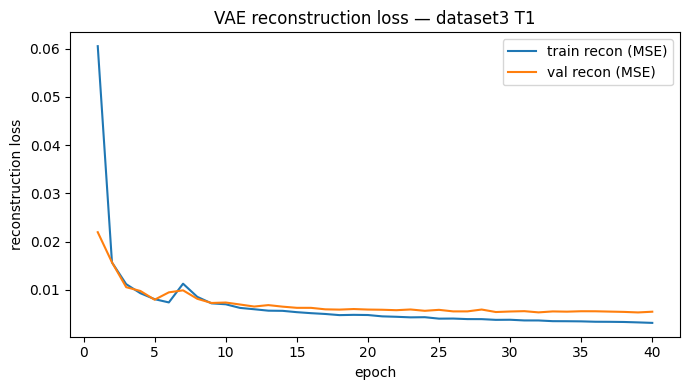

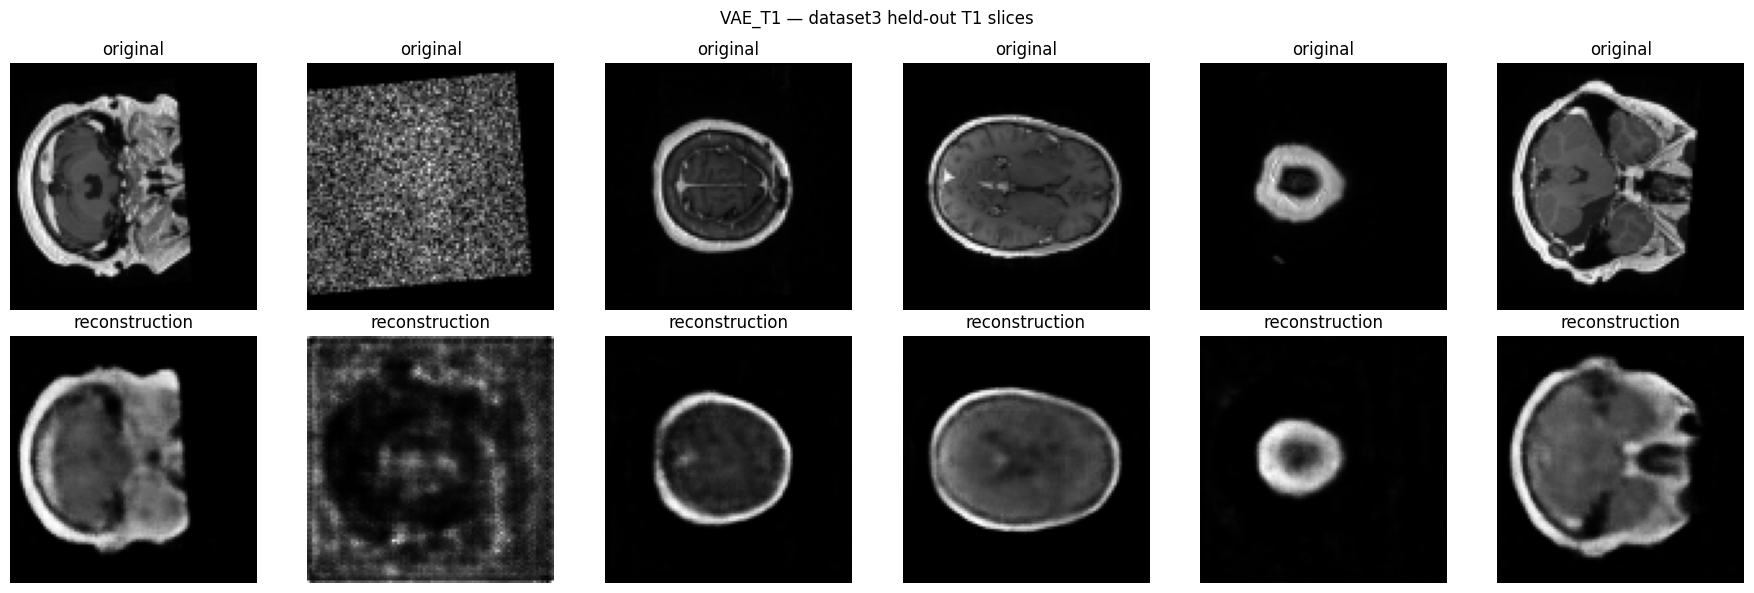

In [8]:
plot_history(t1_history, "VAE reconstruction loss — dataset3 T1")
show_reconstructions(vae_t1, t1_val_dataset, "VAE_T1 — dataset3 held-out T1 slices")

In [9]:
CHECKPOINT_T1.parent.mkdir(parents=True, exist_ok=True)
torch.save(
    {
        "state_dict": vae_t1.state_dict(),
        "image_size": IMAGE_SIZE,
        "latent_dim": LATENT_DIM,
        "num_slices": NUM_SLICES,
        "axis": AXIS,
        "modality": "T1 post-contrast",
        "trained_on": "dataset3 val_queries.csv + test_queries.csv",
    },
    CHECKPOINT_T1,
)
print(f"Saved checkpoint: {CHECKPOINT_T1}")

Saved checkpoint: ../checkpoints/vae_dataset3_t1.pt


## 4. Train `VAE_T2` on dataset3 T2 (gallery) volumes

In [10]:
t2_volume_paths = list_volumes(DATA_ROOT, DATASET3_T2_CSVS, "target_image")
print(f"dataset3 T2 volumes: {len(t2_volume_paths)}")

t2_train_loader, t2_val_loader, t2_val_dataset = build_loaders(t2_volume_paths, "T2")
vae_t2 = ConvVAE().to(DEVICE)
t2_history = train_vae(vae_t2, t2_train_loader, t2_val_loader, EPOCHS, LR, "T2")

dataset3 T2 volumes: 97
[T2] train volumes=82 val volumes=15
[T2] preprocessing done in 22.9s
[T2] epoch 1/40 train_recon=0.10042 val_recon=0.04824
[T2] epoch 5/40 train_recon=0.00880 val_recon=0.00908
[T2] epoch 10/40 train_recon=0.00601 val_recon=0.00700
[T2] epoch 15/40 train_recon=0.00461 val_recon=0.00604
[T2] epoch 20/40 train_recon=0.00397 val_recon=0.00601
[T2] epoch 25/40 train_recon=0.00342 val_recon=0.00550
[T2] epoch 30/40 train_recon=0.00310 val_recon=0.00542
[T2] epoch 35/40 train_recon=0.00279 val_recon=0.00576
[T2] epoch 40/40 train_recon=0.00258 val_recon=0.00561


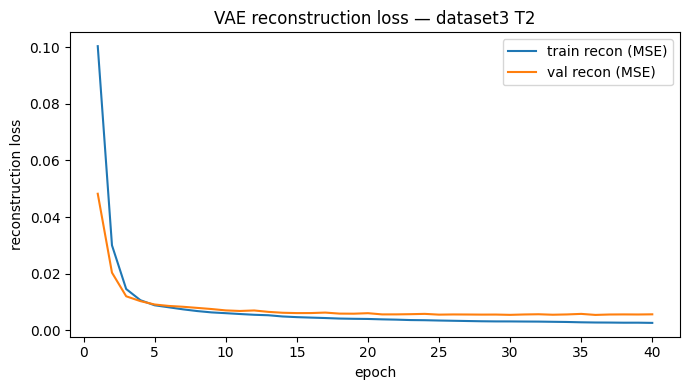

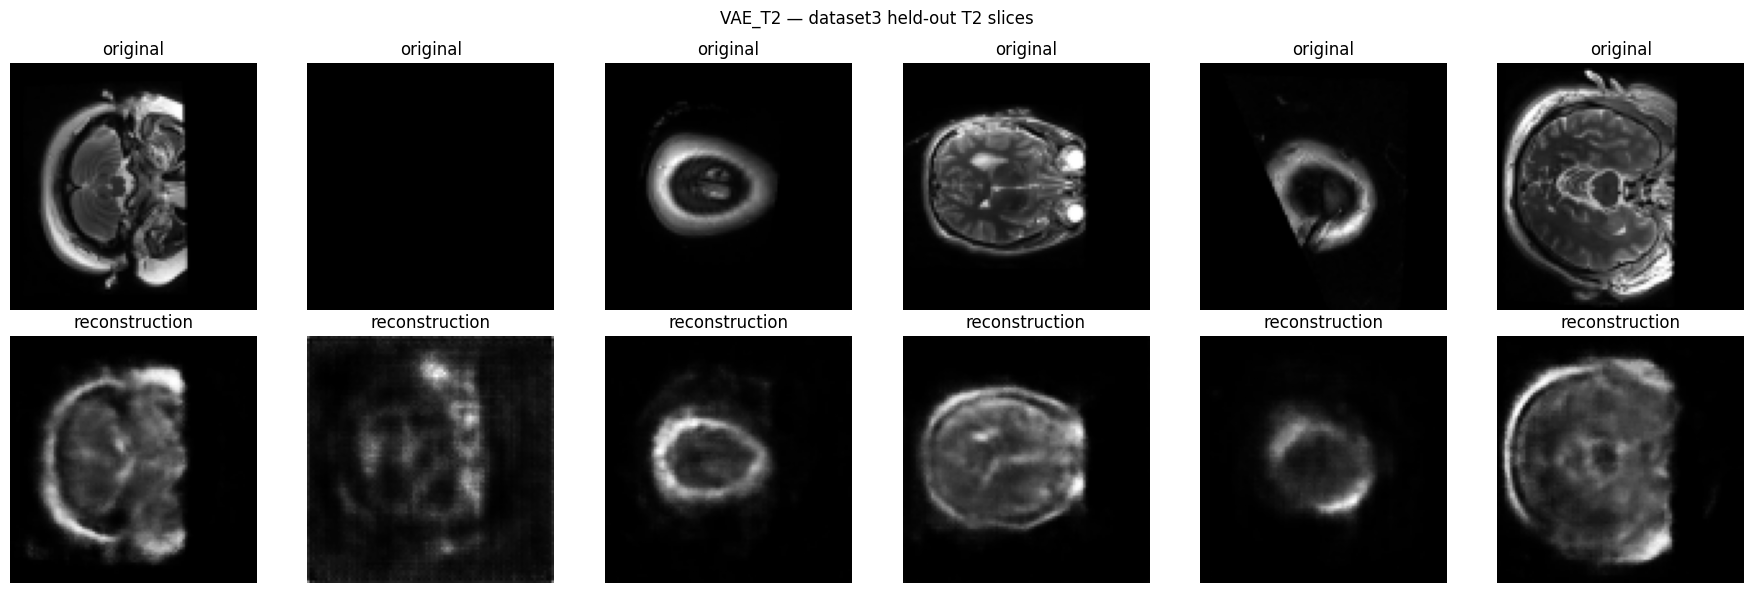

In [11]:
plot_history(t2_history, "VAE reconstruction loss — dataset3 T2")
show_reconstructions(vae_t2, t2_val_dataset, "VAE_T2 — dataset3 held-out T2 slices")

In [12]:
CHECKPOINT_T2.parent.mkdir(parents=True, exist_ok=True)
torch.save(
    {
        "state_dict": vae_t2.state_dict(),
        "image_size": IMAGE_SIZE,
        "latent_dim": LATENT_DIM,
        "num_slices": NUM_SLICES,
        "axis": AXIS,
        "modality": "T2",
        "trained_on": "dataset3 val_gallery.csv + test_gallery.csv",
    },
    CHECKPOINT_T2,
)
print(f"Saved checkpoint: {CHECKPOINT_T2}")

Saved checkpoint: ../checkpoints/vae_dataset3_t2.pt


## 5. VAE-based data augmentation of dataset1

For a sample of `AUG_NUM_PAIRS` labelled dataset1 pairs, each T1 query volume is pushed
through `VAE_T1` and each T2 target volume through `VAE_T2`. For every slice this produces:

- one deterministic reconstruction (decode of `mu`)
- `AUG_SAMPLES_PER_SLICE` stochastic augmentations (decode of `mu + eps * std` for fresh
  `eps ~ N(0, I)` draws) -- new slice variants with the same anatomical content as the
  input but resampled through the dataset3-learned latent prior, usable as additional
  training augmentation beyond geometric transforms.

In [13]:
@torch.no_grad()
def augment_volume(model: ConvVAE, volume_slices: np.ndarray, n_samples: int) -> dict[str, np.ndarray]:
    """slices: (S, H, W) in [0, 1] -> reconstruction + n_samples stochastic decodes, same shape (+ sample dim)."""
    model.eval()
    batch = torch.from_numpy(volume_slices).unsqueeze(1).to(DEVICE)
    mu, logvar = model.encode(batch)
    std = torch.exp(0.5 * logvar)

    reconstruction = model.decode(mu).squeeze(1).cpu().numpy()
    augmented = np.zeros((n_samples, *volume_slices.shape), dtype=np.float32)
    for sample_index in range(n_samples):
        z = mu + std * torch.randn_like(std)
        augmented[sample_index] = model.decode(z).squeeze(1).cpu().numpy()
    return {"reconstruction": reconstruction, "augmented": augmented}


def load_dataset1_pairs_sample(n_pairs: int, seed: int) -> list[dict[str, str]]:
    with DATASET1_TRAIN_PAIRS_CSV.open(newline="") as f:
        rows = list(csv.DictReader(f))
    rng = random.Random(seed)
    return rng.sample(rows, k=min(n_pairs, len(rows)))

In [14]:
pair_rows = load_dataset1_pairs_sample(AUG_NUM_PAIRS, seed=20260628)
print(f"Augmenting {len(pair_rows)} dataset1 pairs (T1 via VAE_T1, T2 via VAE_T2)")

t1_originals, t1_reconstructions, t1_augmented, t1_pair_ids = [], [], [], []
t2_originals, t2_reconstructions, t2_augmented, t2_pair_ids = [], [], [], []

start = time.time()
for row in pair_rows:
    t1_path = resolve_path(DATA_ROOT, row["query_image"])
    t2_path = resolve_path(DATA_ROOT, row["target_image"])

    t1_slices = preprocess_volume(load_nifti(t1_path))
    t2_slices = preprocess_volume(load_nifti(t2_path))

    t1_result = augment_volume(vae_t1, t1_slices, AUG_SAMPLES_PER_SLICE)
    t2_result = augment_volume(vae_t2, t2_slices, AUG_SAMPLES_PER_SLICE)

    t1_originals.append(t1_slices)
    t1_reconstructions.append(t1_result["reconstruction"])
    t1_augmented.append(t1_result["augmented"])
    t1_pair_ids.append(row["query_id"])

    t2_originals.append(t2_slices)
    t2_reconstructions.append(t2_result["reconstruction"])
    t2_augmented.append(t2_result["augmented"])
    t2_pair_ids.append(row["target_id"])

print(f"Augmentation generation done in {time.time() - start:.1f}s")

Augmenting 60 dataset1 pairs (T1 via VAE_T1, T2 via VAE_T2)
Augmentation generation done in 29.0s


### Visualize a few augmented examples (original / reconstruction / 2 stochastic samples)

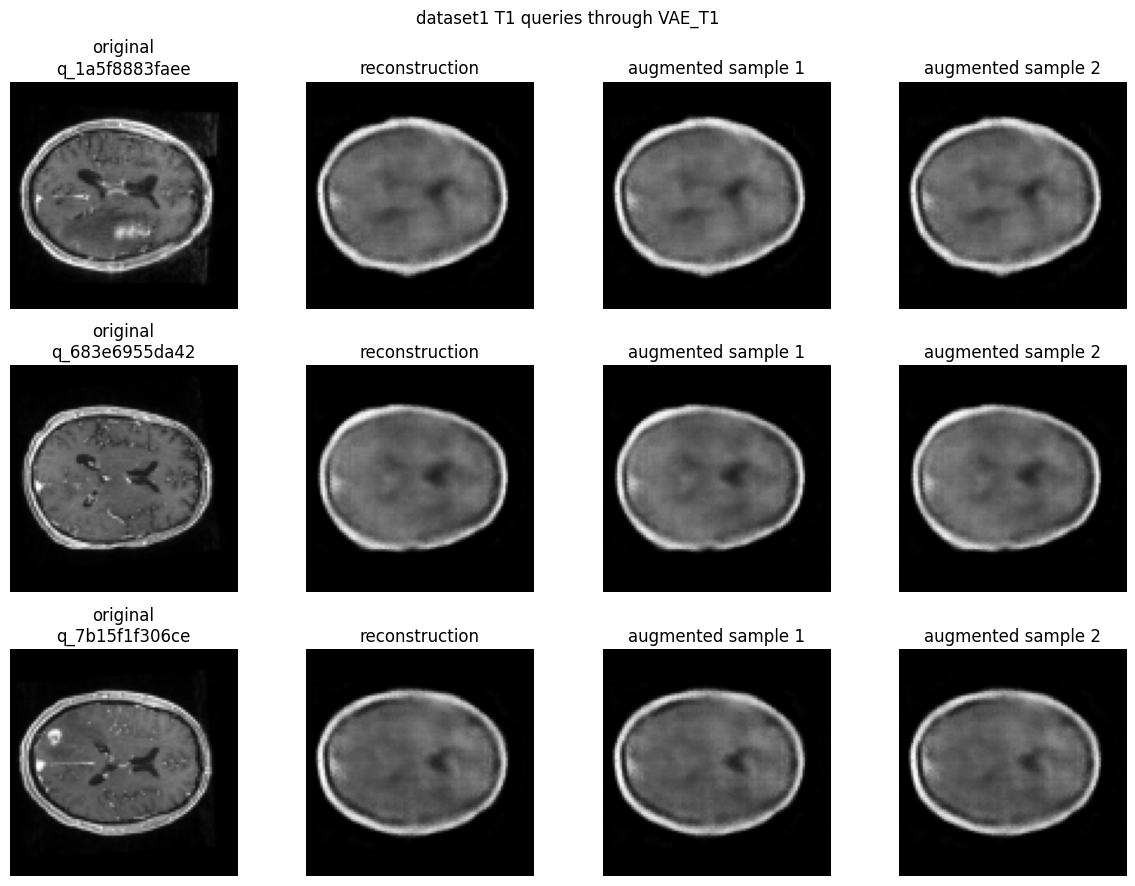

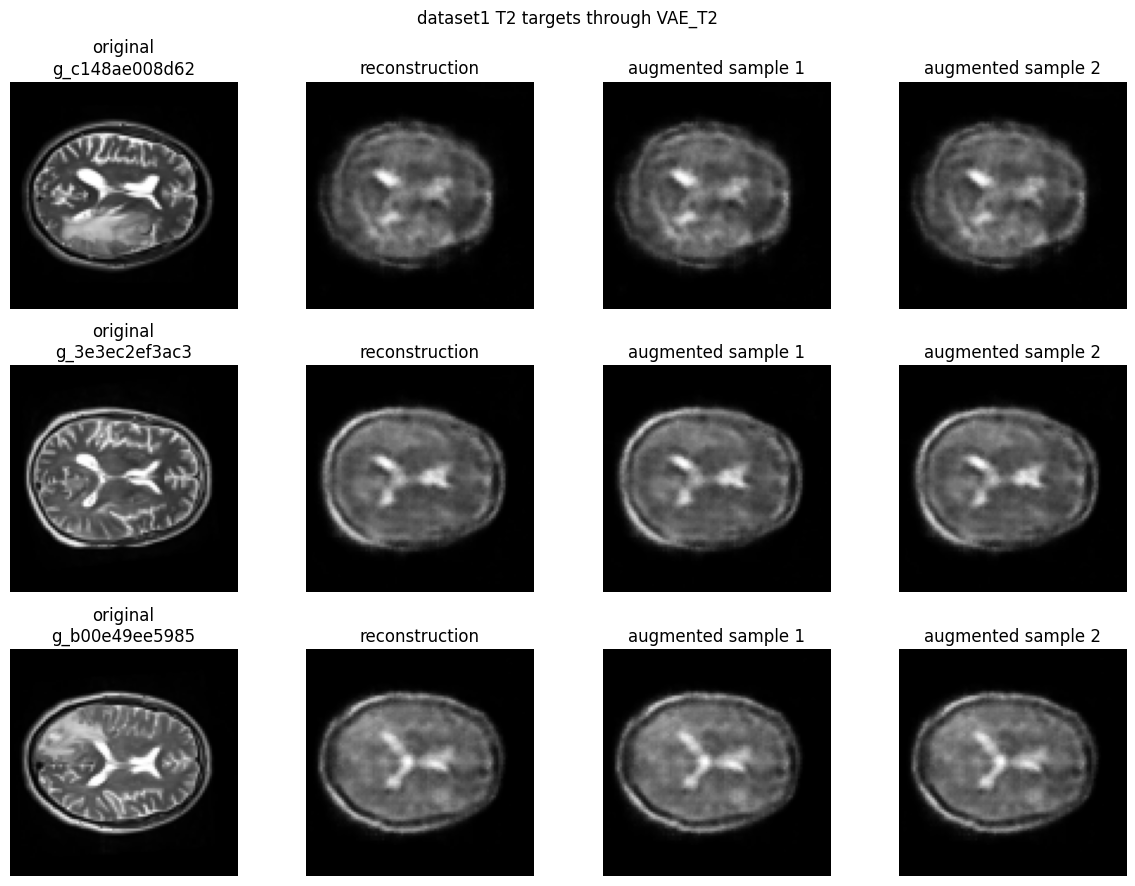

In [15]:
def show_augmentation_grid(originals, reconstructions, augmented, pair_ids, title, n_examples=3, slice_index=None):
    fig, axes = plt.subplots(n_examples, 4, figsize=(12, 3 * n_examples))
    rng = random.Random(1)
    chosen = rng.sample(range(len(originals)), k=min(n_examples, len(originals)))
    for row_index, volume_index in enumerate(chosen):
        s = slice_index if slice_index is not None else originals[volume_index].shape[0] // 2
        axes[row_index, 0].imshow(originals[volume_index][s], cmap="gray")
        axes[row_index, 0].set_title(f"original\n{pair_ids[volume_index]}")
        axes[row_index, 1].imshow(reconstructions[volume_index][s], cmap="gray")
        axes[row_index, 1].set_title("reconstruction")
        for sample_col in range(2):
            axes[row_index, 2 + sample_col].imshow(augmented[volume_index][sample_col, s], cmap="gray")
            axes[row_index, 2 + sample_col].set_title(f"augmented sample {sample_col + 1}")
        for col in range(4):
            axes[row_index, col].axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


show_augmentation_grid(t1_originals, t1_reconstructions, t1_augmented, t1_pair_ids, "dataset1 T1 queries through VAE_T1")
show_augmentation_grid(t2_originals, t2_reconstructions, t2_augmented, t2_pair_ids, "dataset1 T2 targets through VAE_T2")

### Save the augmented dataset1 slices

In [16]:
def save_augmented(originals, reconstructions, augmented, pair_ids, out_path: Path, modality: str) -> None:
    payload = {
        "modality": modality,
        "pair_ids": pair_ids,
        "image_size": IMAGE_SIZE,
        "num_slices": NUM_SLICES,
        "samples_per_slice": AUG_SAMPLES_PER_SLICE,
        "original": torch.from_numpy(np.stack(originals)).to(torch.float16),
        "reconstruction": torch.from_numpy(np.stack(reconstructions)).to(torch.float16),
        "augmented": torch.from_numpy(np.stack(augmented)).to(torch.float16),
    }
    torch.save(payload, out_path)
    print(f"Saved {out_path}  original={payload['original'].shape} augmented={payload['augmented'].shape}")


save_augmented(t1_originals, t1_reconstructions, t1_augmented, t1_pair_ids, AUG_OUT_DIR / "dataset1_t1_augmented.pt", "T1 post-contrast")
save_augmented(t2_originals, t2_reconstructions, t2_augmented, t2_pair_ids, AUG_OUT_DIR / "dataset1_t2_augmented.pt", "T2")

Saved ../data/vae_augmented/dataset1_t1_augmented.pt  original=torch.Size([60, 24, 96, 96]) augmented=torch.Size([60, 3, 24, 96, 96])
Saved ../data/vae_augmented/dataset1_t2_augmented.pt  original=torch.Size([60, 24, 96, 96]) augmented=torch.Size([60, 3, 24, 96, 96])


## 6. Summary

- `checkpoints/vae_dataset3_t1.pt` -- `ConvVAE` trained on dataset3 T1 query volumes.
- `checkpoints/vae_dataset3_t2.pt` -- `ConvVAE` trained on dataset3 T2 gallery volumes.
- `data/vae_augmented/dataset1_t1_augmented.pt` / `dataset1_t2_augmented.pt` -- for
  `AUG_NUM_PAIRS` dataset1 pairs, the original slices, VAE reconstructions, and
  `AUG_SAMPLES_PER_SLICE` stochastic latent-resampled augmentations per slice, per modality.